# 逻辑回归

这个文档用一个尽量简单的二分类例子介绍逻辑回归的基本形式：根据学生的学习时长和练习次数，预测是否能通过考试。

样本标签 $y$ 只有两种取值：

- $y = 1$：通过
- $y = 0$：未通过

逻辑回归虽然名字里有“回归”，但它常用于分类问题。它不会直接输出“通过”或“未通过”，而是先输出一个 0 到 1 之间的概率，再根据阈值做分类判断。


## 1. 数据准备

本例只使用两个数值特征，不涉及特征标准化：

- $x_1$：学习时长，单位为小时
- $x_2$：练习次数，单位为次
- $y$：是否通过考试，$1$ 表示通过，$0$ 表示未通过

示例训练数据如下：

| 编号 | $x_1$ 学习时长 | $x_2$ 练习次数 | $y$ 是否通过 |
| --- | --- | --- | --- |
| 1 | 1 | 1 | 0 |
| 2 | 2 | 1 | 0 |
| 3 | 2 | 3 | 0 |
| 4 | 3 | 2 | 0 |
| 5 | 3 | 4 | 1 |
| 6 | 4 | 3 | 1 |
| 7 | 4 | 5 | 1 |
| 8 | 5 | 4 | 1 |
| 9 | 5 | 6 | 1 |
| 10 | 6 | 5 | 1 |

这个数据集刻意设计得比较简单：学习时长和练习次数越多，通过考试的可能性越高。


## 2. 示例代码

下面的代码使用手写梯度下降训练一个逻辑回归模型。为了突出逻辑回归的基本形式，代码只保留核心步骤：

1. 定义 sigmoid 函数
2. 定义预测概率
3. 定义代价函数
4. 用梯度下降训练参数
5. 用训练后的模型预测新样本


In [8]:
import math


# sigmoid 函数：把任意实数压缩到 0 到 1 之间
def sigmoid(z):
    return 1 / (1 + math.exp(-z))


def predict_probability(sample, w, b):
    z = sum(w[j] * sample[j] for j in range(len(w))) + b
    return sigmoid(z)


In [9]:
# 代价函数：使用二元交叉熵衡量预测概率和真实标签之间的差距
def cost_function(X, y, w, b):
    m = len(X)
    total_cost = 0.0
    epsilon = 1e-15

    for i in range(m):
        f_wb = predict_probability(X[i], w, b)
        f_wb = min(max(f_wb, epsilon), 1 - epsilon)
        total_cost += -y[i] * math.log(f_wb) - (1 - y[i]) * math.log(1 - f_wb)

    return total_cost / m


In [10]:
# 梯度下降：根据所有样本的平均梯度更新一次参数
def gradient_descent(X, y, w, b, alpha):
    m = len(X)
    n = len(w)
    dj_dw = [0.0] * n
    dj_db = 0.0

    for i in range(m):
        f_wb = predict_probability(X[i], w, b)
        error = f_wb - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i][j]

        dj_db += error

    for j in range(n):
        w[j] = w[j] - alpha * dj_dw[j] / m

    b = b - alpha * dj_db / m
    return w, b


In [11]:
# 训练日志格式化：普通数值保留 2 位小数，很小的数值使用科学计数法
def format_log_value(value):
    if math.isinf(value):
        return "inf"
    if value != 0 and abs(value) < 0.01:
        return f"{value:.2e}"
    return f"{value:.2f}"


def format_log_list(values):
    return "[" + ", ".join(format_log_value(value) for value in values) + "]"


def train_model(X, y, alpha=0.1, num_iters=20000, epsilon=1e-8):
    n = len(X[0])
    w = [0.0] * n
    b = 0.0
    j_prev = float("inf")
    history = []
    logged_iters = set()
    recent_logs = []

    def log_iteration(iter_idx, w, b, current_cost, cost_diff):
        print(
            f"[{iter_idx:>6}/{num_iters}]: w = {format_log_list(w)}, "
            f"b = {format_log_value(b)}, j_wb = {format_log_value(current_cost)}, "
            f"j_prev - j_wb = {format_log_value(cost_diff)}"
        )
        logged_iters.add(iter_idx)

    for i in range(num_iters):
        current_cost = cost_function(X, y, w, b)
        history.append(current_cost)

        cost_diff = j_prev - current_cost if j_prev != float("inf") else float("inf")
        current_log = (i, w[:], b, current_cost, cost_diff)
        recent_logs.append(current_log)
        recent_logs = recent_logs[-2:]

        if i % 2000 == 0:
            log_iteration(*current_log)

        if abs(j_prev - current_cost) < epsilon:
            break

        j_prev = current_cost
        w, b = gradient_descent(X, y, w, b, alpha)

    for final_log in recent_logs:
        if final_log[0] not in logged_iters:
            log_iteration(*final_log)

    return w, b, history


In [12]:
# 使用两个特征训练逻辑回归模型：学习时长、练习次数
X = [
    [1, 1],
    [2, 1],
    [2, 3],
    [3, 2],
    [3, 4],
    [4, 3],
    [4, 5],
    [5, 4],
    [5, 6],
    [6, 5],
]

y = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

w, b, history = train_model(X, y, alpha=0.1, num_iters=100000, epsilon=1e-5)

print(
    f"【训练完成】w = {format_log_list(w)}, b = {format_log_value(b)}, "
    f"j_wb = {format_log_value(history[-1])}, epsilon = {format_log_value(1e-8)}"
)

# 使用训练后的模型预测新学生是否可能通过考试
X_test = [
    [2, 2],
    [3, 5],
    [4, 2],
    [5, 5],
]

probabilities = [predict_probability(sample, w, b) for sample in X_test]

for sample, prob in zip(X_test, probabilities):
    label = 1 if prob >= 0.5 else 0
    result = "通过" if label == 1 else "未通过"
    print(f"学习时长和练习次数 x = {sample}，【预测通过概率】= {prob:.2%}，【预测结果】= {result}")


[     0/100000]: w = [0.00, 0.00], b = 0.00, j_wb = 0.69, j_prev - j_wb = inf
[  2000/100000]: w = [1.26, 1.34], b = -7.55, j_wb = 0.11, j_prev - j_wb = 3.04e-05
[  4000/100000]: w = [1.72, 1.75], b = -10.18, j_wb = 0.07, j_prev - j_wb = 1.16e-05
[  4429/100000]: w = [1.79, 1.81], b = -10.61, j_wb = 0.06, j_prev - j_wb = 1.00e-05
[  4430/100000]: w = [1.79, 1.81], b = -10.61, j_wb = 0.06, j_prev - j_wb = 1.00e-05
【训练完成】w = [1.79, 1.81], b = -10.61, j_wb = 0.06, epsilon = 1.00e-08
学习时长和练习次数 x = [2, 2]，【预测通过概率】= 3.22%，【预测结果】= 未通过
学习时长和练习次数 x = [3, 5]，【预测通过概率】= 97.88%，【预测结果】= 通过
学习时长和练习次数 x = [4, 2]，【预测通过概率】= 54.41%，【预测结果】= 通过
学习时长和练习次数 x = [5, 5]，【预测通过概率】= 99.94%，【预测结果】= 通过


## 3. 逻辑回归的基本形式

逻辑回归先计算一个线性组合：

$$
z = w_1 x_1 + w_2 x_2 + b
$$

在本例中：

- $x_1$ 表示学习时长
- $x_2$ 表示练习次数
- $w_1$ 和 $w_2$ 是两个特征对应的权重
- $b$ 是偏置

然后把 $z$ 代入 sigmoid 函数：

$$
\hat{y} = g(z) = \frac{1}{1 + e^{-z}}
$$

$\hat{y}$ 可以理解为预测 $y=1$ 的概率，也就是预测“通过考试”的概率。


## 4. Sigmoid 函数

sigmoid 函数的形式为：

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

它的作用是把任意实数 $z$ 转换到 0 到 1 之间，所以很适合表示概率。

- 当 $z$ 很大时，$g(z)$ 接近 1，表示模型认为通过概率很高
- 当 $z$ 很小时，$g(z)$ 接近 0，表示模型认为通过概率很低
- 当 $z = 0$ 时，$g(z) = 0.5$，表示模型正好处在分类边界上

通常可以使用 0.5 作为分类阈值：

$$
\text{预测结果} =
\begin{cases}
1, & \hat{y} \ge 0.5 \\
0, & \hat{y} < 0.5
\end{cases}
$$


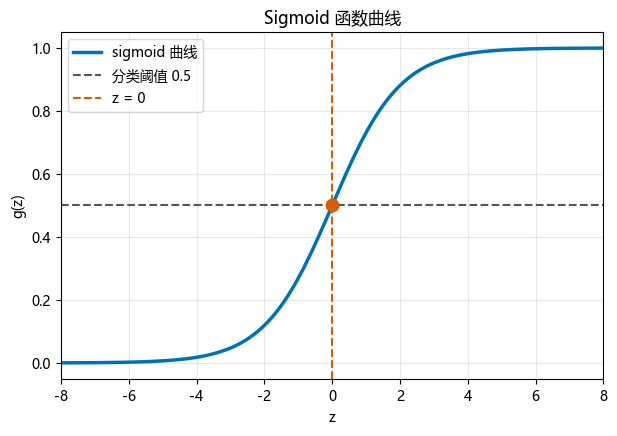

In [13]:
# 绘制 sigmoid 函数曲线
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

z_values = [value / 10 for value in range(-80, 81)]
g_values = [sigmoid(z) for z in z_values]

plt.figure(figsize=(7, 4.5))
plt.plot(z_values, g_values, color="#0072b2", linewidth=2.5, label="sigmoid 曲线")
plt.axhline(0.5, color="#555555", linestyle="--", linewidth=1.5, label="分类阈值 0.5")
plt.axvline(0, color="#d55e00", linestyle="--", linewidth=1.5, label="z = 0")
plt.scatter([0], [0.5], color="#d55e00", s=80, zorder=3)

plt.xlim(-8, 8)
plt.ylim(-0.05, 1.05)
plt.xlabel("z")
plt.ylabel("g(z)")
plt.title("Sigmoid 函数曲线")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. 代价函数

逻辑回归通常使用二元交叉熵作为代价函数：

$$
J(\vec{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]
$$

它衡量的是预测概率和真实标签之间的差距：

- 如果真实标签是 $1$，预测概率越接近 1，代价越小
- 如果真实标签是 $0$，预测概率越接近 0，代价越小
- 如果模型很自信但判断错误，代价会变得很大


## 6. 参数更新

对每一个权重 $w_j$，梯度为：

$$
\frac{\partial J(\vec{w}, b)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) x_j^{(i)}
$$

对偏置 $b$，梯度为：

$$
\frac{\partial J(\vec{w}, b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})
$$

然后使用学习率 $\alpha$ 更新参数：

$$
w_j := w_j - \alpha \frac{\partial J}{\partial w_j}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$


## 7. 什么是决策边界

逻辑回归输出的是概率。若使用 0.5 作为分类阈值，那么：

- $\hat{y} \ge 0.5$ 时，预测为 $1$
- $\hat{y} < 0.5$ 时，预测为 $0$

因为 sigmoid 函数在 $z = 0$ 时正好等于 0.5，所以分类边界对应：

$$
z = 0
$$

在本例中：

$$
z = w_1 x_1 + w_2 x_2 + b
$$

因此决策边界就是：

$$
w_1 x_1 + w_2 x_2 + b = 0
$$

如果把它写成 $x_2$ 关于 $x_1$ 的形式：

$$
x_2 = -\frac{w_1 x_1 + b}{w_2}
$$

这是一条直线。直线的一侧会被模型预测为通过，另一侧会被预测为未通过。二维逻辑回归的决策边界通常是一条直线；如果有三个特征，决策边界会变成一个平面；更高维时则是超平面。


In [14]:
# 查看训练后模型对应的决策边界
b_sign = "+" if b >= 0 else "-"
b_abs = abs(b)

print(f"决策边界：{format_log_value(w[0])} * x1 + {format_log_value(w[1])} * x2 {b_sign} {format_log_value(b_abs)} = 0")
print(f"等价形式：x2 = ({format_log_value(b_abs)} - {format_log_value(w[0])} * x1) / {format_log_value(w[1])}")


决策边界：1.79 * x1 + 1.81 * x2 - 10.61 = 0
等价形式：x2 = (10.61 - 1.79 * x1) / 1.81


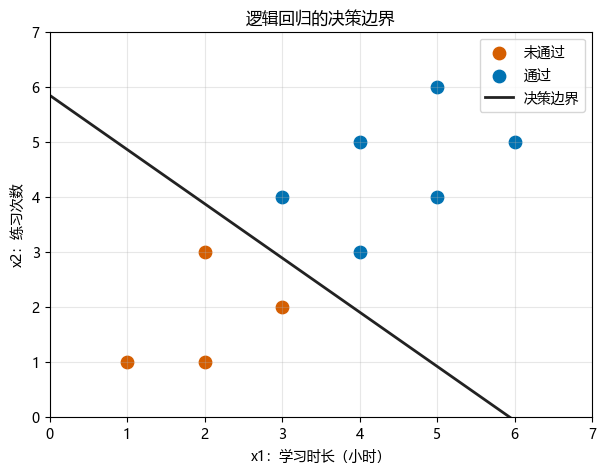

In [15]:
# 绘制训练样本和决策边界
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

not_passed = [sample for sample, label in zip(X, y) if label == 0]
passed = [sample for sample, label in zip(X, y) if label == 1]

boundary_x1 = [0, 7]
boundary_x2 = [-(w[0] * x1 + b) / w[1] for x1 in boundary_x1]

plt.figure(figsize=(7, 5))
plt.scatter(
    [sample[0] for sample in not_passed],
    [sample[1] for sample in not_passed],
    color="#d55e00",
    label="未通过",
    s=80,
)
plt.scatter(
    [sample[0] for sample in passed],
    [sample[1] for sample in passed],
    color="#0072b2",
    label="通过",
    s=80,
)
plt.plot(boundary_x1, boundary_x2, color="#222222", linewidth=2, label="决策边界")

plt.xlim(0, 7)
plt.ylim(0, 7)
plt.xlabel("x1：学习时长（小时）")
plt.ylabel("x2：练习次数")
plt.title("逻辑回归的决策边界")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. 如何判断收敛

一种常见方式，是比较这一轮和上一轮的代价函数变化是否已经足够小：

$$
\left| J_{\text{prev}} - J(\vec{w}, b) \right| < \epsilon
$$

其中：

- $J_{\text{prev}}$ 表示上一轮的代价函数值
- $J(\vec{w}, b)$ 表示当前这一轮的代价函数值
- $\epsilon$ 表示收敛阈值，是一个很小的正数

如果满足这个条件，就可以认为模型已经基本收敛。


## 9. 训练过程总结

逻辑回归的训练目标，就是不断调整参数向量 $\vec{w}$ 和偏置 $b$，让代价函数 $J(\vec{w}, b)$ 尽可能小。

| 符号 | 释义 |
| --- | --- |
| $\vec{x}$ | 特征向量，本例中包含学习时长和练习次数 |
| $y$ | 真实标签，1 表示通过，0 表示未通过 |
| $\hat{y}$ | 预测为通过的概率 |
| $\vec{w}$ | 权重向量 |
| $b$ | 偏置 |
| $\alpha$ | 学习率 |
| $J(\vec{w}, b)$ | 代价函数 |
| $z = \vec{w} \cdot \vec{x} + b$ | 线性组合 |
| $z = 0$ | 决策边界 |

完整流程可以概括为：

1. 输入特征 $x_1$ 和 $x_2$
2. 计算线性组合 $z = w_1x_1 + w_2x_2 + b$
3. 通过 sigmoid 得到概率 $\hat{y}$
4. 根据真实标签计算代价函数
5. 用梯度下降更新 $w_1$、$w_2$ 和 $b$
6. 训练完成后，用 $\hat{y} \ge 0.5$ 做分类判断
